In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
config_path = "experiments/benchmark_output_files/human_lymph_node.yaml"
panel_output_path = "results/publication_oup_vrepro/figures/panels/panel_human_lymph_node.pdf"

In [3]:
from src.experiments_analysis.plots_ismb import model_name_replacement_dict, color_dict
import yaml
from pathlib import Path as P

cfg = yaml.safe_load(open(config_path))

output_dir = cfg["output_dir"]

global_structure_analysis_folder = P(output_dir) / "global_structure_analysis"

In [4]:
bottom_right_region = (slice(2200, 3000), slice(3000, None))
striped_region_zoom = (slice(3100, 3250), slice(2675, 2825))

regions = {
    "bottom right region": bottom_right_region,
    "striped_region_zoom": striped_region_zoom,
}

colors_region = {
    "bottom right region": "yellow",
    "striped_region_zoom": "yellow",
}

abbr_region = {
    "bottom right region": "A",
    "striped_region_zoom": "B",
}

to_plot = ["original", "b2c", "b2c-sym", "ours"]

auto.py (21): IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
bioimageio_utils.py (2): pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


Using vmin, vmax = 1.0 156.0


/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/experiments_analysis/analysis_plots.py:424: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/experiments_analysis/analysis_plots.py:424: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


overall striping intensity


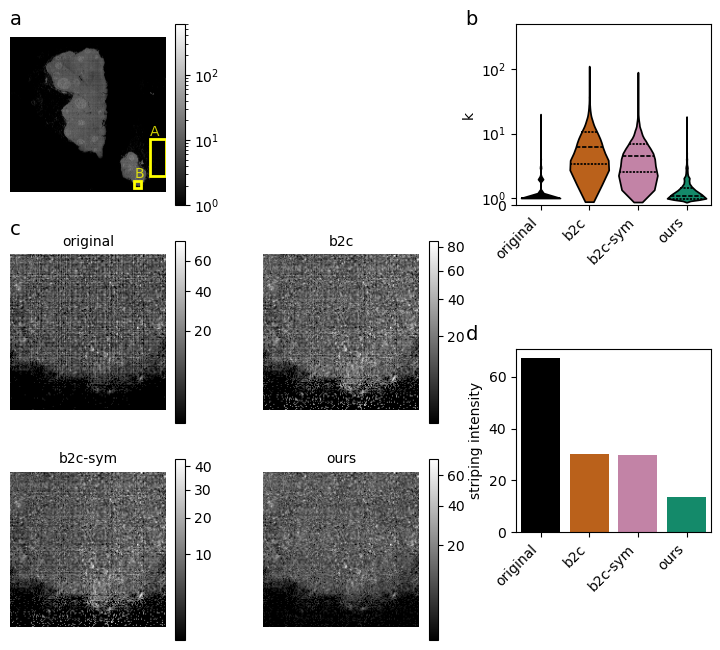

In [5]:
from src.experiments_analysis.analysis_plots import (
    compare_destriped_data_plots, striping_intensity_quantification_region_barplot, intensity_profile_in_region_violinplot, region_overview_plot
)
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, PowerNorm
from matplotlib.gridspec import GridSpec

from src.utilities.matplotlib_utils import save_pdf_temp_intermediate

fig = plt.figure(layout="constrained", figsize=(7.009, 7))
gs = GridSpec(3, 3, width_ratios=[1,1, 1], height_ratios=[1, 1,1], figure=fig, hspace=0.2, wspace = 0.3)

base_font_size = 10
base_font_size = 10
plt.rcParams.update(
    {
        "font.size": base_font_size,  # base font size
        "axes.labelsize": base_font_size,  # x/y label size
        "axes.titlesize": base_font_size,  # title size
        "xtick.labelsize": base_font_size,  # x tick labels
        "ytick.labelsize": base_font_size,  # y tick labels
        "legend.fontsize": base_font_size,  # legend
    }
)

fontsize_title = 10

# global plot upper left
ax = fig.add_subplot(gs[0, 0])
imshow_kwargs = {}
rectangle_kwargs = {"alpha": 1}
# otherwise we don't see anything
vmin = 1
vmax = 600
norm = LogNorm(vmin, vmax)

height_colorbar = 0.092
region_overview_plot(
    "original",
    regions,
    colors_region,
    abbr_region,
    global_structure_analysis_folder,
    model_name_replacement_dict,
    norm,
    height_colorbar,
    imshow_kwargs=imshow_kwargs,
    rectangle_kwargs=rectangle_kwargs,
    axes = ax,
    colorbar_on = False
)

mappable = None
if ax.images:
    mappable = ax.images[-1]
elif ax.collections:
    mappable = ax.collections[-1]
else:
    raise RuntimeError("No obvious mappable found on this Axes")

# remove existing colorbar axes (same as above)
for cax in list(ax.figure.axes):
    if cax.get_label() == "counts":
        cax.remove()

cbar = ax.figure.colorbar(mappable, ax=ax, location="right")

# counts in region A
ax = fig.add_subplot(gs[0, 2])
ax = intensity_profile_in_region_violinplot(
    bottom_right_region,
    to_plot,
    global_structure_analysis_folder,
    color_dict,
    model_name_replacement_dict,
    axes = ax
)
ax.set_yscale("symlog", linthresh=1, linscale=0.1)
ax.set_ylim(0, 500)

# zoom region B
axes = [
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[2, 0]),
    fig.add_subplot(gs[2, 1]),
]
axes = compare_destriped_data_plots(
    to_plot,
    global_structure_analysis_folder,
    striped_region_zoom,
    model_name_replacement_dict,
    axes=axes,
    colorbar_same_scale=False,
)

[ax.images[0].set_norm(PowerNorm(gamma=0.5)) for ax in axes]
[ax.axis("off") for ax in axes]

## striping intensity on the right
gs_striping_intensity = gs[1:,2].subgridspec(
    3, 1, height_ratios=[1, 1.7, 1], wspace=0.0, hspace=0.0
)
ax = fig.add_subplot(gs_striping_intensity[1, 0])
striping_intensity_quantification_region_barplot(
    output_dir,
    striped_region_zoom,
    to_plot,
    color_dict,
    model_name_replacement_dict,
    cyto_select=False,
    axes = ax
)

fig.canvas.draw()

letters_fontsize = 14
fig.text(0.0, 1.0, "a", ha="left", va="top", fontsize=letters_fontsize)
fig.text(0.65, 1.0, "b", ha="left", va="top", fontsize=letters_fontsize)
fig.text(0.0, 0.7, "c", ha="left", va="top", fontsize=letters_fontsize)
fig.text(0.65, 0.55, "d", ha="left", va="top", fontsize=letters_fontsize)

save_pdf_temp_intermediate("temp_outputs", panel_output_path, dpi=600)

plt.show()